# Building large cutouts with the `era5-edh` module
## Prerequisites
To understand the content in this module, you may want to read:
- [the installation instructions](https://atlite.readthedocs.io/en/latest/installation.html)
- [example cookbook for building a cutout](https://atlite.readthedocs.io/en/latest/examples/create_cutout.html)
- [introduction to the `era5-edh` module](https://atlite.readthedocs.io/en/latest/examples/comparing_era5_sources_cds_vs_edh.html)

If you're all set up and comfortable with building cutouts - let's go!

## Background
In this example we'll demonstrate how to build large (~hundreds of GiBs) cutouts with the `era5-edh` module. We cover two important levels - scheduling and compression.

### Chunking and scheduling
A large cutout is likely larger than your computer's memory. We cannot process it all at once. Instead, we divide it into small independent *chunks*, and process them one-by-one. For each chunk, we download the required data, perform computations on it, and save to disk. This limits memory usage to the *in-flight* chunks that are currently being processed, which can be much less than the size of our cutout. 

`atlite` achieves this with the help of a library called [`dask`](https://www.dask.org/). `dask` handles the heavy lifting of deciding which chunks to download when, how long to keep them in memory for etc. The part of dask that does this is called a [scheduler](https://docs.dask.org/en/stable/scheduler-overview.html). There are many schedulers available, and `atlite` doesn't specify which scheduler to use.

By default, `dask` uses a local threaded scheduler, which is simple to set up, and fine for most users. However, it is not memory-aware, and will happily crash your computer if you throw too much data at it. In this notebook we'll show you how to use the `distributed` scheduler, which is more sophisticated. It ensures you never exceed a memory threshold, gives you access to a nice dashboard for monitoring your computations and more. 

### Compression
Another issue to keep in mind when processing large amounts of data is compression, which can decrease cutout size on your disk substantially. Your compressor needs to be fast, and you need to be careful about how much data you need to keep. If you use an older, slower compression algorithm (such as `zlib`), compressing data may take as much time as downloading it.

## The code 
Let's start by importing the relevant libraries. You will need some extra stuff beyond what `atlite` gets installed with. Install them with your favourite package manager, here we use `pip`:

```bash
pip install dask[distributed] bokeh 
```

`bokeh` is optional. `dask` uses it for plotting monitoring data.

Then we import:

In [1]:
from time import time

from dask.distributed import Client, LocalCluster
from dask.distributed.diagnostics import MemorySampler

import atlite

First, let's set up a `cluster`. A `cluster` is a set of `workers` -  processes that dask can pass chunks to for parallel processing. `Workers` could be separate computers communicating over a network, or local processes/threads communicating on the same machine. Here we use a `LocalCluster`.

You can set the number of workers, limit memory (the `4GiB` below is per worker, not total) and more. `dask` will try to ensure that workers never pass the memory limit. If they get close, they'll save their results to disk, or get stopped. You can read more about the cluster API [here](https://docs.dask.org/en/stable/deploying-python.html).

**For `atlite` you should keep per-worker memory to 3GiB or more.**

In [2]:
cluster = LocalCluster(memory_limit="4GiB", n_workers=4, processes=True)
client = Client(cluster)

Now let's create a cutout. Note the choice of module (`era5-edh`) and the extent. We're downloading data for a large area (the whole world), for an entire year. The final cutout will be around 175GiB, but we only assigned 16 GiB of RAM for processing it.

In [3]:
BOUNDS = (-180, -90, 180, 90)
TIME = ("2013-01-01", "2013-12-31")
NAME = f"whole_world_{int(time())}"

cutout = atlite.Cutout(path=NAME, bounds=BOUNDS, time=slice(*TIME), module="era5-edh")

Now let's set up the cutout preparation. This is where the data will actually be downloaded and saved to disk. We pass a compression config to `cutout.prepare()`. Here we use the `zstd` compression algorithm (which is modern and fast) and the `GranularBitRound` filter. This filter will save only the first 5 significant digits of each value we generate, which generates a relative error of 1.8e-5 and saves a ton of drive space. To learn more about this filter and it's precision tradeoffs, look [here](https://docs.unidata.ucar.edu/netcdf-c/4.9.0/md_quantize.html).

We also use a memory sampler to demonstrate the type of statistics that you can get with a `distributed` scheduler. If you chose to install the `bokeh` library, after you run the next cell you should be able to open a [dashboard](https://docs.dask.org/en/stable/dashboard.html) under [http://localhost:8787/](http://localhost:8787/) where you can monitor the computation.

In [4]:
COMPRESSION = {
    "compression": "zstd",
    "complevel": 3,
    "significant_digits": 5,
    "quantize_mode": "GranularBitRound",
}

ms = MemorySampler()

with ms.sample("prepare cutout", interval=5):
    cutout.prepare(compression=COMPRESSION)

Now we can look at the timeseries of memory usage during the download. You can see that it remained well below the 16 GiB that we specified. If you looked at the dashboard during the download, you'll have noticed that dask intelligently started saving chunks to disk when it got close to our memory limit.

We can also inspect the size of the compressed cutout and it's on-disk size. The compression ratio is almost 3x.

<Cutout "whole_world_1780611095">
 x = -180.00 ⟷ 179.75, dx = 0.25
 y = -90.00 ⟷ 89.75, dy = 0.25
 time = 2013-01-01 ⟷ 2013-12-31, dt = h
 module = era5-edh
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']

cutout size: 175.87 GB
uncompressed size: 508.62 GB
compression ratio: 2.89



<Axes: xlabel='time', ylabel='Cluster memory (GiB)'>

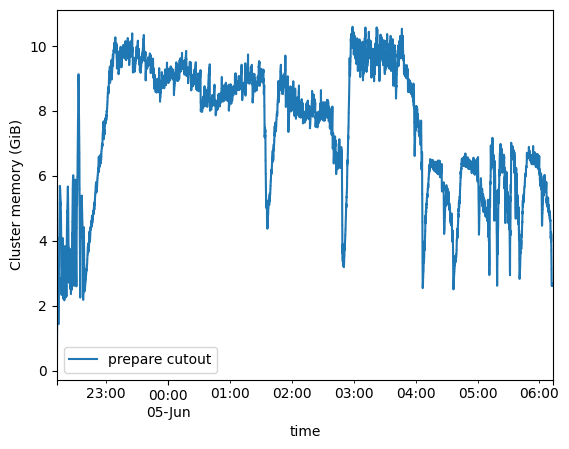

In [22]:
import os

disk_size = os.path.getsize(NAME + ".nc")
uncompressed_size = cutout.data.nbytes

print(
    f"{cutout}\n\ncutout size: {disk_size / 1e9:.2f} GB\nuncompressed size: {uncompressed_size / 1e9:.2f} GB\ncompression ratio: {uncompressed_size / disk_size:.2f}\n"
)

ms.plot()